# Cross-Modal Diagnostic Observability — Stage T1-R

## Directed Diagnostic Evidence Transport (DDET) mechanism kill test

This notebook tests a theory-derived, zero-fitted operational proxy rather than fitting another edge classifier:

$$
\widehat q_{s\to t}
= \widetilde c_{s\to t}\Phi^{-1}(\widehat A_t^{\mathrm{own}}),
\qquad
c_{s\to t}=\operatorname{Corr}_t(f_s(Z_t),f_t(Z_t)).
$$

The exact DDET theorem uses class-centred target covariance and a target-optimal direction. Here $\widetilde c$ is ordinary marginal score correlation, so the displayed expression is an empirically falsifiable approximation, not a second exact theorem. It uses the existing 30-edge, 14-domain, 4-modality development library. The target diagnostic axis is label-informed, so this is an **oracle mechanism-discovery test**, not a deployable label-free method and not independent validation.

The notebook also demonstrates the label-free non-identifiability theorem and a minimal-target-witness simulation.

**Possible decisions**

- all 8 frozen gates pass: authorise development of the cross-fitted minimal-witness estimator;
- any gate fails: terminate the single-axis DDET route and require a new diagnostic-subspace theory.

Neither decision authorises Stage 12 or any locked-blind access. CPU runtime is sufficient. Run all cells once from a clean runtime.


In [1]:
# @title T1-R-0. Mount Drive, resolve frozen inputs, verify parents, and seal protocol
import hashlib, itertools, json, os, platform, sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm, pearsonr, spearmanr

try:
    from IPython.display import display
except Exception:
    display = print

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    pass

LOCAL_MODE = bool(os.environ.get('DDET_LOCAL_MODE'))
DEFAULT_ROOT = Path('/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability') if IN_COLAB else Path.cwd()
PROJECT_ROOT = Path(os.environ.get('CDO_PROJECT_ROOT', str(DEFAULT_ROOT)))
CODE_ROOT = PROJECT_ROOT/'05_Code'/'Cross_Modal' if not LOCAL_MODE else Path.cwd()
CM_ROOT = PROJECT_ROOT/'06_Data_Records'/'Cross_Modal' if not LOCAL_MODE else Path('/tmp/DDET_Local_Record')
RESULT_ROOT = CM_ROOT/'StageT1-R_Development_Only_DDET_Mechanism_Kill_Test_v0.1'
P0,P1,P2,P3,P4 = [RESULT_ROOT/x for x in [
    '00_Protocol','01_Theorem_Demonstrations','02_Real_Edge_Mechanism',
    '03_Uncertainty_And_Gates','04_Results'
]]
for p in [CODE_ROOT,P0,P1,P2,P3,P4]: p.mkdir(parents=True, exist_ok=True)

NOTEBOOK_NAME = 'CrossModal_StageT1-R_Development_Only_DDET_Mechanism_Kill_Test_v0.1.ipynb'
NOTEBOOK_PATH = CODE_ROOT/NOTEBOOK_NAME
EDGE_NAME = 'Stage11F-R_FourModality_Eligible_Edge_Library_v0.2.csv'
THEORY_NAME = 'Directed_Diagnostic_Evidence_Transport_Theory_and_Method_v0.2.md'
PREREG_NAME = 'StageT1-R_DDET_Development_Only_Mechanism_Kill_Test_Preregistration_v0.1.md'
EXPECTED_EDGE_SHA256 = 'f074467614321e4162a3aa4ad982b62edfa362d6238edeb2f69be6d4d50f09a9'
EXPECTED_THEORY_SHA256 = 'ab732ed3065bf586624c457e8588d0b9f548d131e23f449846037a5631165d4a'
EXPECTED_PREREG_SHA256 = 'df75df8432b9303dbd394a13f2cea74c388ad265d51370b17373928e7b446940'
LOCKED_MARKERS = ['BUSI_CAIRO_2019','OASBUD_2017','DERM7PT_2019']
SEED = 20260722
N_BOOTSTRAP = 10000

THRESHOLDS = {
    'global_spearman_min': 0.60,
    'cluster_ci_lower_strict_min': 0.0,
    'permutation_p_max': 0.01,
    'within_modality_positive_required': 4,
    'within_modality_rho_0_50_required': 3,
    'lomo_spearman_min': 0.60,
    'auc_mae_max': 0.08,
    'direction_sign_accuracy_min': 0.70,
    'direction_delta_spearman_min': 0.50,
    'mechanistic_gain_min': 0.25,
}

EMBEDDING_NAMES = {
    'DeepDRiD':'DeepDRiD_Canonical_ResNet50V2_L2_Embeddings_v0.1.npy',
    'EyePACS_2015':'EyePACS_2015_Canonical_ResNet50V2_L2_Embeddings_v0.1.npy',
    'APTOS_2019':'APTOS_2019_Canonical_ResNet50V2_L2_Embeddings_v0.1.npy',
    'IDRiD':'IDRiD_Canonical_ResNet50V2_L2_Embeddings_v0.1.npy',
    'ISIC_UDA1':'ISIC_UDA1_Frozen_ResNet50V2_L2_Embeddings_v0.1.npz',
    'ISIC_MSK1':'ISIC_MSK1_Frozen_ResNet50V2_L2_Embeddings_v0.1.npz',
    'HAM10000':'HAM10000_Frozen_ResNet50V2_L2_Embeddings_v0.1.npz',
    'TBX11K':'TBX11K_Frozen_ResNet50V2_L2_Embeddings_v0.1.npz',
    'Montgomery_CXR':'Montgomery_CXR_Frozen_ResNet50V2_L2_Embeddings_v0.1.npz',
    'Shenzhen_CXR':'Shenzhen_CXR_Frozen_ResNet50V2_L2_Embeddings_v0.1.npz',
    'BUSI_WHU_2025_V3':'BUSI_WHU_2025_V3_Canonical_ResNet50_IMAGENET1K_V2_L2_Embeddings_v0.1.npy',
    'BUS_BRA_2024':'BUS_BRA_2024_Canonical_ResNet50_IMAGENET1K_V2_L2_Embeddings_v0.1.npy',
    'BUS_UCLM_2025_V3':'BUS_UCLM_2025_V3_Canonical_ResNet50_IMAGENET1K_V2_L2_Embeddings_v0.1.npy',
    'RODRIGUES_BUI_2017':'RODRIGUES_BUI_2017_Canonical_ResNet50_IMAGENET1K_V2_L2_Embeddings_v0.1.npy',
}
AXIS_NAMES = {
    'DeepDRiD':'DeepDRiD_Frozen_Source_Axis_v0.1.npz',
    'EyePACS_2015':'EyePACS_2015_Frozen_Source_Axis_v0.1.npz',
    'APTOS_2019':'APTOS_2019_PostUnseal_Frozen_Development_Axis_v0.1.npz',
    'IDRiD':'IDRiD_PostUnseal_Frozen_Development_Axis_v0.1.npz',
    'ISIC_UDA1':'ISIC_UDA1_Frozen_Source_Axis_v0.1.npz',
    'ISIC_MSK1':'ISIC_MSK1_Frozen_Source_Axis_v0.1.npz',
    'HAM10000':'HAM10000_Frozen_Source_Axis_v0.1.npz',
    'TBX11K':'TBX11K_Frozen_Source_Axis_v0.1.npz',
    'Montgomery_CXR':'Montgomery_CXR_Frozen_Source_Axis_v0.1.npz',
    'Shenzhen_CXR':'Shenzhen_CXR_Frozen_Source_Axis_v0.1.npz',
    'BUSI_WHU_2025_V3':'BUSI_WHU_2025_V3_Frozen_Development_Source_Axis_v0.1.npz',
    'BUS_BRA_2024':'BUS_BRA_2024_Frozen_Development_Source_Axis_v0.1.npz',
    'BUS_UCLM_2025_V3':'BUS_UCLM_2025_V3_Frozen_Development_Source_Axis_v0.1.npz',
    'RODRIGUES_BUI_2017':'RODRIGUES_BUI_2017_Frozen_Development_Source_Axis_v0.1.npz',
}

def now(): return datetime.now(timezone.utc).isoformat()
def sha_file(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as f:
        for b in iter(lambda:f.read(1024*1024),b''): h.update(b)
    return h.hexdigest()
def sha_json(value):
    return hashlib.sha256(json.dumps(value,sort_keys=True,separators=(',',':'),ensure_ascii=False).encode()).hexdigest()
def canonical_csv(frame):
    return frame.fillna('').to_csv(index=False,lineterminator='\n',float_format='%.12g')
def write_text_once(path,text):
    path=Path(path)
    if path.exists(): assert path.read_text(encoding='utf-8')==text,f'Replay mismatch: {path}'
    else: path.write_text(text,encoding='utf-8')
def write_csv_once(path,frame): write_text_once(path,canonical_csv(frame))
def write_json_once(path,value): write_text_once(path,json.dumps(value,indent=2,ensure_ascii=False)+'\n')
def verify_self(path,field):
    x=json.loads(Path(path).read_text(encoding='utf-8')); claim=x[field]
    y=dict(x); y.pop(field)
    assert sha_json(y)==claim,f'Self-hash mismatch: {path}'
    return x
def seal(path,payload,hash_field,time_field):
    path=Path(path)
    if path.exists():
        x=verify_self(path,hash_field)
        for k,v in payload.items(): assert x[k]==v,f'Sealed field changed: {k}'
        return x
    x=dict(payload); x[time_field]=now(); x[hash_field]=sha_json(x); write_json_once(path,x); return x
def notebook_source_sha256(path):
    x=json.loads(Path(path).read_text(encoding='utf-8'))
    cells=[]
    for c in x.get('cells',[]):
        if c.get('cell_type') not in {'code','markdown'}: continue
        s=c.get('source',[]); s=''.join(s) if isinstance(s,list) else str(s)
        cells.append({'cell_type':c['cell_type'],'source':s.replace('\r\n','\n')})
    return sha_json(cells)

if LOCAL_MODE:
    EDGE_PATH=Path.cwd()/'stage11f_edges.csv'; THEORY_PATH=Path.cwd()/THEORY_NAME; PREREG_PATH=Path.cwd()/PREREG_NAME
    AXIS_PATHS={d:Path.cwd()/'axes_actual'/f'{d}.npz' for d in AXIS_NAMES}
    EMBEDDING_PATHS={d:next((Path.cwd()/'embeddings_actual').glob(d+'.*')) for d in EMBEDDING_NAMES}
    stage11g={'decision':'TERMINATE_DDO2_V0_1_PREDICTIVE_LAW_ROUTE_DO_NOT_ACQUIRE_MORE_EDGES_SOLELY_TO_REPAIR_CLASS_COUNTS','stage12_authorised':False,'locked_blind_assets_touched':False}
else:
    RETINAL_ROOT=PROJECT_ROOT/'06_Data_Records'/'Retinal_DR'/'Prospective_Retinal_Blind_Test_v0.1'
    STAGE5=RETINAL_ROOT/'Stage5_Source_Recoverability_And_Axis_Freeze_v0.1'
    STAGE5B=RETINAL_ROOT/'Stage5B_Label_Free_Target_Scoring_And_Prediction_Freeze_v0.1'
    STAGE7=RETINAL_ROOT/'Stage7_PostUnseal_FourDomain_Transportability_Discovery_And_DDO2_Prototype_v0.1'
    STAGE8=CM_ROOT/'Stage8_CrossModality_EdgeLibrary_Expansion_v0.1'
    STAGE8B=CM_ROOT/'Stage8B_NLM_Chest_Radiography_Access_Completion_v0.1'
    STAGE11E=CM_ROOT/'Stage11E-R_Development_Only_Source_Recoverability_And_Axis_Freeze_v0.1'
    EDGE_PATH=CM_ROOT/'Stage11F-R_Development_Only_Directed_Edge_Assembly_And_Fit_Readiness_v0.2'/'03_Expanded_Edge_Library'/EDGE_NAME
    THEORY_PATH=PROJECT_ROOT/'03_Theory'/'Directed_Diagnostic_Evidence_Transport_v0.2'/THEORY_NAME
    PREREG_PATH=PROJECT_ROOT/'04_Study_Design'/PREREG_NAME
    AXIS_PATHS={
        'DeepDRiD':STAGE5/'02_Frozen_Source_Axes'/AXIS_NAMES['DeepDRiD'],
        'EyePACS_2015':STAGE5/'02_Frozen_Source_Axes'/AXIS_NAMES['EyePACS_2015'],
        'APTOS_2019':STAGE7/'02_DDO2_Prototype'/'Frozen_PostUnseal_Source_Axes'/AXIS_NAMES['APTOS_2019'],
        'IDRiD':STAGE7/'02_DDO2_Prototype'/'Frozen_PostUnseal_Source_Axes'/AXIS_NAMES['IDRiD'],
        **{d:STAGE8/'03_Frozen_Source_Axes'/AXIS_NAMES[d] for d in ['ISIC_UDA1','ISIC_MSK1','HAM10000','TBX11K']},
        **{d:STAGE8B/'03_Frozen_Source_Axes'/AXIS_NAMES[d] for d in ['Montgomery_CXR','Shenzhen_CXR']},
        **{d:STAGE11E/'03_Frozen_Source_Axes'/AXIS_NAMES[d] for d in ['BUSI_WHU_2025_V3','BUS_BRA_2024','BUS_UCLM_2025_V3','RODRIGUES_BUI_2017']},
    }
    EMBEDDING_PATHS={
        'DeepDRiD':STAGE5/'01_Frozen_Embeddings'/EMBEDDING_NAMES['DeepDRiD'],
        'EyePACS_2015':STAGE5/'01_Frozen_Embeddings'/EMBEDDING_NAMES['EyePACS_2015'],
        'APTOS_2019':STAGE5B/'01_Label_Free_Scores'/EMBEDDING_NAMES['APTOS_2019'],
        'IDRiD':STAGE5B/'01_Label_Free_Scores'/EMBEDDING_NAMES['IDRiD'],
        **{d:STAGE8/'02_Frozen_Embeddings'/EMBEDDING_NAMES[d] for d in ['ISIC_UDA1','ISIC_MSK1','HAM10000','TBX11K']},
        **{d:STAGE8B/'02_Frozen_Embeddings'/EMBEDDING_NAMES[d] for d in ['Montgomery_CXR','Shenzhen_CXR']},
        **{d:STAGE11E/'01_Frozen_Embeddings'/EMBEDDING_NAMES[d] for d in ['BUSI_WHU_2025_V3','BUS_BRA_2024','BUS_UCLM_2025_V3','RODRIGUES_BUI_2017']},
    }
    required_paths=[EDGE_PATH,THEORY_PATH,PREREG_PATH,*AXIS_PATHS.values(),*EMBEDDING_PATHS.values()]
    missing=[str(p) for p in required_paths if not p.is_file()]
    assert not missing,'Missing frozen inputs:\n'+'\n'.join(missing)
    STAGE11G_FINAL=CM_ROOT/'Stage11G-R_Development_Only_DDO2_Decisive_Viability_Kill_Test_v0.1'/'04_Results'/'Stage11G-R_Complete_v0.1.json'
    assert STAGE11G_FINAL.is_file(),f'Missing Stage 11G-R final: {STAGE11G_FINAL}'
    stage11g=verify_self(STAGE11G_FINAL,'final_record_sha256')

assert NOTEBOOK_PATH.is_file(),f'Notebook must be saved in {CODE_ROOT} before Run all'
assert sha_file(EDGE_PATH)==EXPECTED_EDGE_SHA256
assert sha_file(THEORY_PATH)==EXPECTED_THEORY_SHA256
assert sha_file(PREREG_PATH)==EXPECTED_PREREG_SHA256
assert str(stage11g['decision']).startswith('TERMINATE_DDO2_V0_1_PREDICTIVE_LAW_ROUTE')
assert stage11g['stage12_authorised'] is False and stage11g['locked_blind_assets_touched'] is False
resolved='|'.join(map(str,[EDGE_PATH,THEORY_PATH,PREREG_PATH,*AXIS_PATHS.values(),*EMBEDDING_PATHS.values()]))
assert not any(m.lower() in resolved.lower() for m in LOCKED_MARKERS),'Locked asset marker resolved'

PROTOCOL=P0/'StageT1-R_DDET_Mechanism_Protocol_Seal_v0.1.json'
PARENT_COMMIT=P0/'StageT1-R_Frozen_Input_Commitment_v0.1.csv'
ENVIRONMENT=P0/'StageT1-R_Execution_Environment_v0.1.json'
protocol_payload={
    'stage':'StageT1-R','analysis':'development_only_oracle_mechanism_kill_test',
    'theory_sha256':sha_file(THEORY_PATH),'preregistration_sha256':sha_file(PREREG_PATH),
    'parent_edge_library_sha256':sha_file(EDGE_PATH),'notebook_source_sha256':notebook_source_sha256(NOTEBOOK_PATH),
    'random_seed':SEED,'bootstrap_replicates':N_BOOTSTRAP,
    'permutation_scheme':'exact_product_of_within_modality_target_signature_permutations',
    'thresholds':THRESHOLDS,'edge_outcome_coefficients_fitted':False,
    'target_axis_is_label_informed':True,'stage12_authorised':False,'locked_blind_assets_touched':False,
}
protocol=seal(PROTOCOL,protocol_payload,'seal_sha256','sealed_utc')
commit=[]
for role,path in [('edge_library',EDGE_PATH),('theory',THEORY_PATH),('preregistration',PREREG_PATH)]:
    commit.append({'role':role,'dataset':'','path':str(path),'size_bytes':path.stat().st_size,'sha256':sha_file(path)})
for d,p in AXIS_PATHS.items(): commit.append({'role':'frozen_axis','dataset':d,'path':str(p),'size_bytes':p.stat().st_size,'sha256':sha_file(p)})
for d,p in EMBEDDING_PATHS.items(): commit.append({'role':'frozen_embedding','dataset':d,'path':str(p),'size_bytes':p.stat().st_size,'sha256':sha_file(p)})
write_csv_once(PARENT_COMMIT,pd.DataFrame(commit))
write_json_once(ENVIRONMENT,{'created_utc':now(),'python':sys.version,'platform':platform.platform(),'numpy':np.__version__,'pandas':pd.__version__,'scipy':__import__('scipy').__version__})
print('Protocol seal:',protocol['seal_sha256'])
print('Frozen edge library:',sha_file(EDGE_PATH),'/ 30 edges expected')
print('Resolved frozen axes / embeddings:',len(AXIS_PATHS),'/',len(EMBEDDING_PATHS))
print('Stage 11G-R termination verified; blind remains prohibited.')


Mounted at /content/drive
Protocol seal: 5655c7b4d5b156481a92c130abc07d89f716cf9ce582df65dbc8a24eaea6e00a
Frozen edge library: f074467614321e4162a3aa4ad982b62edfa362d6238edeb2f69be6d4d50f09a9 / 30 edges expected
Resolved frozen axes / embeddings: 14 / 14
Stage 11G-R termination verified; blind remains prohibited.


In [2]:
# @title T1-R-1. Demonstrate the transport identity, nuisance invariance, and label-free impossibility theorem
rng=np.random.default_rng(SEED)
synthetic=[]

# Exact binormal identity across rotations, checked by Monte Carlo.
n=50000; d_target=2.0
angles=np.linspace(0,np.pi,13)
for theta in angles:
    delta=np.array([d_target,0.0]); w=np.array([np.cos(theta),np.sin(theta)])
    xp=rng.normal(size=(n,2))+delta/2; xn=rng.normal(size=(n,2))-delta/2
    # Paired Monte Carlo probability has the exact AUC expectation and avoids a quadratic rank computation.
    empirical=float(np.mean((xp@w)>(xn@w)))
    predicted=float(norm.cdf(np.cos(theta)*d_target/np.sqrt(2)))
    synthetic.append({'experiment':'binormal_rotation','parameter':float(theta),'empirical_auc':empirical,'predicted_auc':predicted,'absolute_error':abs(empirical-predicted)})
rotation=pd.DataFrame(synthetic)
identity_max_error=float(rotation.absolute_error.max())

# Nuisance-only mean shift in the score-orthogonal dimension.
y=np.r_[np.zeros(n,dtype=int),np.ones(n,dtype=int)]
base=np.vstack([rng.normal([-1,0],[1,1],size=(n,2)),rng.normal([1,0],[1,1],size=(n,2))])
shifted=base.copy(); shifted[:,1]+=8.0
def auc_from_scores(labels,scores):
    a=scores[labels==1]; b=scores[labels==0]
    # Mann-Whitney via ranks, with continuous scores so ties are negligible.
    ranks=pd.Series(np.r_[a,b]).rank(method='average').to_numpy()[:len(a)]
    return float((ranks.sum()-len(a)*(len(a)+1)/2)/(len(a)*len(b)))
nuisance_auc_before=auc_from_scores(y,base[:,0]); nuisance_auc_after=auc_from_scores(y,shifted[:,0])
nuisance_mean_shift=float(np.linalg.norm(shifted.mean(0)-base.mean(0)))

# Same target marginal, opposite conditional label mechanisms.
z=rng.normal(size=100000); y_plus=(z>0).astype(int); y_minus=(z<0).astype(int)
auc_plus=auc_from_scores(y_plus,z); auc_minus=auc_from_scores(y_minus,z)
marginal_identity=np.array_equal(z,z.copy())

theorem_checks=pd.DataFrame([
    {'check':'binormal_transport_identity','observed':identity_max_error,'required':'<=0.015','passed':identity_max_error<=0.015},
    {'check':'nuisance_shift_changes_marginal_not_auc','observed':abs(nuisance_auc_after-nuisance_auc_before),'required':'<=0.005 with mean shift >=5','passed':abs(nuisance_auc_after-nuisance_auc_before)<=0.005 and nuisance_mean_shift>=5},
    {'check':'identical_marginal_opposite_label_mechanism','observed':auc_plus-auc_minus,'required':'>=0.99','passed':marginal_identity and auc_plus-auc_minus>=0.99},
])
assert theorem_checks.passed.all(),theorem_checks
write_csv_once(P1/'StageT1-R_Synthetic_Transport_Identity_v0.1.csv',rotation)
write_csv_once(P1/'StageT1-R_Theorem_Demonstration_Checks_v0.1.csv',theorem_checks)
display(theorem_checks)
print('Identity max |AUC error|:',round(identity_max_error,5))
print('Nuisance mean shift / AUC change:',round(nuisance_mean_shift,3),'/',round(abs(nuisance_auc_after-nuisance_auc_before),6))
print('Same marginal, AUC+ / AUC-:',round(auc_plus,4),'/',round(auc_minus,4))


,check,observed,required,passed
0,binormal_transport_identity,0.00579,<=0.015,True
1,nuisance_shift_changes_marginal_not_auc,0.00000,<=0.005 with mean shift >=5,True
2,identical_marginal_opposite_label_mechanism,1.00000,>=0.99,True


Identity max |AUC error|: 0.00579
Nuisance mean shift / AUC change: 8.0 / 0.0
Same marginal, AUC+ / AUC-: 1.0 / 0.0


In [3]:
# @title T1-R-2. Compute the zero-fitted marginal diagnostic-function proxy on all 30 frozen edges
def load_embedding(path):
    obj=np.load(path,allow_pickle=False)
    if isinstance(obj,np.ndarray): return np.asarray(obj,dtype=np.float64)
    return np.asarray(obj['embedding'],dtype=np.float64)
def load_axis(path):
    z=np.load(path,allow_pickle=True)
    if 'coefficient_raw' in z.files: w,b=z['coefficient_raw'],z['intercept_raw']
    else: w,b=z['raw_coefficient'],z['raw_intercept']
    return np.asarray(w,dtype=np.float64).reshape(-1),float(np.asarray(b).reshape(-1)[0])

edges=pd.read_csv(EDGE_PATH)
assert len(edges)==30 and edges.edge_id.nunique()==30 and edges.modality.nunique()==4
assert len(set(edges.source.astype(str))|set(edges.target.astype(str)))==14
axes={d:load_axis(p) for d,p in AXIS_PATHS.items()}
embeddings={d:load_embedding(p) for d,p in EMBEDDING_PATHS.items()}
assert all(x.ndim==2 and x.shape[1]==2048 and np.isfinite(x).all() for x in embeddings.values())
assert all(len(w)==2048 and np.isfinite(w).all() and np.isfinite(b) for w,b in axes.values())

own_auc=edges.groupby('source').source_validation_auc.first().to_dict()
# Frozen values from the source recoverability records for domains without authorised outgoing edges.
own_auc.update({'EyePACS_2015':0.5964725853449888,'BUS_UCLM_2025_V3':0.665961945032})
assert set(own_auc)==set(axes)

rows=[]; target_scores={}; score_cache={}
for modality,g in edges.groupby('modality'):
    domains=sorted(set(g.source)|set(g.target))
    for target in sorted(g.target.unique()):
        x=embeddings[target]
        scores={d:x@axes[d][0]+axes[d][1] for d in domains}
        target_scores[target]=scores
        for source in sorted(g.source.unique()):
            for candidate in domains:
                score_cache[(source,target,candidate)]=pearsonr(scores[source],scores[candidate]).statistic
for r in edges.itertuples(index=False):
    c=float(score_cache[(r.source,r.target,r.target)])
    qt=float(norm.ppf(np.clip(own_auc[r.target],1e-6,1-1e-6)))
    pred_q=c*qt; obs_q=float(norm.ppf(np.clip(r.target_auc,1e-6,1-1e-6)))
    rows.append({'edge_id':r.edge_id,'source':r.source,'target':r.target,'modality':r.modality,
        'target_auc':r.target_auc,'observed_q':obs_q,'target_own_auc':own_auc[r.target],
        'target_own_q':qt,'function_alignment':c,'predicted_q':pred_q,
        'predicted_auc':float(norm.cdf(pred_q)),'absolute_error_auc':abs(float(norm.cdf(pred_q))-r.target_auc)})
mechanism=pd.DataFrame(rows)
write_csv_once(P2/'StageT1-R_DDET_Thirty_Edge_Mechanism_Table_v0.1.csv',mechanism)
display(mechanism[['source','target','modality','function_alignment','predicted_auc','target_auc','absolute_error_auc']])
print('Global Spearman:',spearmanr(mechanism.predicted_q,mechanism.observed_q).statistic)
print('AUC MAE:',mechanism.absolute_error_auc.mean())


,source,target,modality,function_alignment,predicted_auc,target_auc,absolute_error_auc
0,DeepDRiD,EyePACS_2015,retinal_fundus,0.296172,0.528832,0.634402,0.105570
1,DeepDRiD,APTOS_2019,retinal_fundus,0.359902,0.750300,0.675678,0.074622
2,DeepDRiD,IDRiD,retinal_fundus,0.628435,0.771751,0.782662,0.010910
3,APTOS_2019,EyePACS_2015,retinal_fundus,0.279258,0.527188,0.655973,0.128786
4,APTOS_2019,DeepDRiD,retinal_fundus,0.655812,0.827013,0.884040,0.057028
5,APTOS_2019,IDRiD,retinal_fundus,0.637861,0.775114,0.835165,0.060051
6,IDRiD,EyePACS_2015,retinal_fundus,0.244354,0.523794,0.584276,0.060482
7,IDRiD,DeepDRiD,retinal_fundus,0.257539,0.644344,0.772828,0.128485
8,IDRiD,APTOS_2019,retinal_fundus,0.444935,0.798145,0.779473,0.018672
9,ISIC_UDA1,ISIC_MSK1,dermoscopy,0.308085,0.564579,0.596712,0.032133


Global Spearman: 0.8838709677419355
AUC MAE: 0.06290220417652144


In [4]:
# @title T1-R-3. Run cluster bootstrap, exact conditional permutation, modality, baseline, and directionality audits
def weighted_corr(x,y,w):
    x,y,w=map(lambda a:np.asarray(a,dtype=float),(x,y,w))
    keep=np.isfinite(x)&np.isfinite(y)&np.isfinite(w)&(w>0); x,y,w=x[keep],y[keep],w[keep]
    if len(x)<3 or np.ptp(x)==0 or np.ptp(y)==0: return np.nan
    w=w/w.sum(); mx,my=np.sum(w*x),np.sum(w*y)
    return float(np.sum(w*(x-mx)*(y-my))/np.sqrt(np.sum(w*(x-mx)**2)*np.sum(w*(y-my)**2)))

global_rho=float(spearmanr(mechanism.predicted_q,mechanism.observed_q).statistic)
global_pearson=float(pearsonr(mechanism.predicted_q,mechanism.observed_q).statistic)
auc_mae=float(mechanism.absolute_error_auc.mean())
rank_x=mechanism.predicted_q.rank(method='average').to_numpy(); rank_y=mechanism.observed_q.rank(method='average').to_numpy()
rng=np.random.default_rng(SEED); boot=[]
for rep in range(N_BOOTSTRAP):
    counts={}
    for modality,g in mechanism.groupby('modality'):
        domains=sorted(set(g.source)|set(g.target)); sampled=rng.choice(domains,size=len(domains),replace=True)
        cc=pd.Series(sampled).value_counts().to_dict(); counts.update({(modality,d):cc.get(d,0) for d in domains})
    w=np.array([counts[(r.modality,r.source)]*counts[(r.modality,r.target)] for r in mechanism.itertuples(index=False)],dtype=float)
    rho=weighted_corr(rank_x,rank_y,w)
    if np.isfinite(rho): boot.append({'replicate':rep,'weighted_rank_correlation':rho,'positive_weight_edges':int(np.sum(w>0))})
bootstrap=pd.DataFrame(boot); cluster_ci=[float(bootstrap.weighted_rank_correlation.quantile(q)) for q in [0.025,0.975]]
write_csv_once(P3/'StageT1-R_TwoWay_Dataset_Cluster_Bootstrap_v0.1.csv',bootstrap)

# Exact product of all within-modality target-signature permutations: 4!*3!*3!*4! = 20,736.
modality_targets={m:sorted(g.target.unique()) for m,g in mechanism.groupby('modality')}
perm_lists={m:list(itertools.permutations(t)) for m,t in modality_targets.items()}
modalities=sorted(modality_targets); perm_rho=[]
for combo in itertools.product(*(perm_lists[m] for m in modalities)):
    mapping={}
    for m,shuffled in zip(modalities,combo): mapping.update(dict(zip(modality_targets[m],shuffled)))
    pq=[]
    for r in edges.itertuples(index=False):
        wrong=mapping[r.target]; c=score_cache[(r.source,r.target,wrong)]
        pq.append(c*norm.ppf(np.clip(own_auc[wrong],1e-6,1-1e-6)))
    perm_rho.append(float(spearmanr(pq,mechanism.observed_q).statistic))
perm_rho=np.asarray(perm_rho); perm_p=float((1+np.sum(perm_rho>=global_rho))/(1+len(perm_rho)))
permutation=pd.DataFrame({'permutation_index':np.arange(len(perm_rho)),'spearman':perm_rho})
write_csv_once(P3/'StageT1-R_Exact_Modality_Stratified_Target_Signature_Permutation_v0.1.csv',permutation)

within={m:float(spearmanr(g.predicted_q,g.observed_q).statistic) for m,g in mechanism.groupby('modality')}
lomo={m:float(spearmanr(mechanism.loc[mechanism.modality!=m,'predicted_q'],mechanism.loc[mechanism.modality!=m,'observed_q']).statistic) for m in sorted(mechanism.modality.unique())}
source_q=mechanism.source.map(lambda d:norm.ppf(np.clip(own_auc[d],1e-6,1-1e-6)))
baselines={
    'source_own_q_only':float(spearmanr(source_q,mechanism.observed_q).statistic),
    'target_own_q_only':float(spearmanr(mechanism.target_own_q,mechanism.observed_q).statistic),
    'function_alignment_only':float(spearmanr(mechanism.function_alignment,mechanism.observed_q).statistic),
    'ddet_product':global_rho,
}
pair_rows=[]
for _,a in mechanism.iterrows():
    rev=mechanism[(mechanism.source==a.target)&(mechanism.target==a.source)]
    if len(rev)!=1 or a.source>a.target: continue
    b=rev.iloc[0]
    pair_rows.append({'pair':f'{a.source}<->{a.target}','observed_delta_auc':a.target_auc-b.target_auc,'predicted_delta_auc':a.predicted_auc-b.predicted_auc})
pairs=pd.DataFrame(pair_rows)
direction_accuracy=float(np.mean(np.sign(pairs.observed_delta_auc)==np.sign(pairs.predicted_delta_auc)))
direction_rho=float(spearmanr(pairs.predicted_delta_auc,pairs.observed_delta_auc).statistic)
best_single=max(baselines['source_own_q_only'],baselines['target_own_q_only'])
mechanistic_gain=global_rho-best_single

summary={
    'global_spearman':global_rho,'global_pearson':global_pearson,'auc_mae':auc_mae,
    'cluster_bootstrap_ci95':cluster_ci,'exact_permutations':len(perm_rho),'permutation_p_one_sided':perm_p,
    'permutation_rho_q95':float(np.quantile(perm_rho,0.95)),'within_modality_spearman':within,
    'leave_one_modality_out_spearman':lomo,'fixed_baselines':baselines,
    'reciprocal_pairs':len(pairs),'direction_sign_accuracy':direction_accuracy,
    'direction_delta_spearman':direction_rho,'mechanistic_gain_over_best_single_domain_strength':mechanistic_gain,
}
write_json_once(P3/'StageT1-R_DDET_Mechanism_Summary_v0.1.json',summary)
write_csv_once(P3/'StageT1-R_Reciprocal_Directionality_Audit_v0.1.csv',pairs)
display(pd.DataFrame([summary | {'within_modality_spearman':json.dumps(within),'leave_one_modality_out_spearman':json.dumps(lomo),'fixed_baselines':json.dumps(baselines)}]))


,global_spearman,global_pearson,auc_mae,cluster_bootstrap_ci95,exact_permutations,permutation_p_one_sided,permutation_rho_q95,within_modality_spearman,leave_one_modality_out_spearman,fixed_baselines,reciprocal_pairs,direction_sign_accuracy,direction_delta_spearman,mechanistic_gain_over_best_single_domain_strength
0,0.883871,0.906716,0.062902,"[0.585194571615309, 0.9652526767924714]",20736,0.000675,0.660623,"{""breast_ultrasound"": 0.7999999999999999, ""che...","{""breast_ultrasound"": 0.8558441558441559, ""che...","{""source_own_q_only"": -0.04486632291710551, ""t...",12,0.75,0.727273,0.423669


In [5]:
# @title T1-R-4. Simulate the minimal diagnostic witness and adaptive abstention principle
rng=np.random.default_rng(SEED+1); p=20; delta=np.zeros(p); delta[0]=2.0
theta=np.deg2rad(40); ws=np.zeros(p); ws[0]=np.cos(theta); ws[1]=np.sin(theta)
true_auc=float(norm.cdf((ws@delta)/np.sqrt(2*(ws@ws))))
sizes=[8,16,32,64,128,256]; witness_rows=[]
test0=rng.normal(size=(10000,p))-delta/2; test1=rng.normal(size=(10000,p))+delta/2
test=np.vstack([test0,test1]); ytest=np.r_[np.zeros(len(test0),dtype=int),np.ones(len(test1),dtype=int)]
source_test=test@ws
for n_total in sizes:
    for rep in range(250):
        n0=n_total//2; n1=n_total-n0
        x0=rng.normal(size=(n0,p))-delta/2; x1=rng.normal(size=(n1,p))+delta/2
        wt=x1.mean(0)-x0.mean(0)  # identity-covariance shrinkage special case
        target_test=test@wt
        align=float(pearsonr(source_test,target_test).statistic)
        own=auc_from_scores(ytest,target_test)
        pred=float(norm.cdf(align*norm.ppf(np.clip(own,1e-6,1-1e-6))))
        witness_rows.append({'witness_labels':n_total,'replicate':rep,'predicted_auc':pred,'true_auc':true_auc,'absolute_error':abs(pred-true_auc)})
witness=pd.DataFrame(witness_rows)
witness_summary=witness.groupby('witness_labels').agg(median_absolute_error=('absolute_error','median'),q05_auc=('predicted_auc',lambda s:s.quantile(.05)),q95_auc=('predicted_auc',lambda s:s.quantile(.95)),median_auc=('predicted_auc','median')).reset_index()
witness_summary['interval_crosses_tau_0_70']=(witness_summary.q05_auc<0.70)&(witness_summary.q95_auc>=0.70)
write_csv_once(P1/'StageT1-R_Minimal_Diagnostic_Witness_Simulation_v0.1.csv',witness)
write_csv_once(P1/'StageT1-R_Minimal_Diagnostic_Witness_Summary_v0.1.csv',witness_summary)
display(witness_summary)
print('True transfer AUC:',round(true_auc,4),'; witness error contracts with label budget.')


,witness_labels,median_absolute_error,q05_auc,q95_auc,median_auc,interval_crosses_tau_0_70
0,8,0.183358,0.543224,0.797292,0.677315,True
1,16,0.108168,0.645418,0.831718,0.752506,True
2,32,0.054101,0.735216,0.852331,0.806572,False
3,64,0.016179,0.807257,0.872682,0.845899,False
4,128,0.010881,0.839641,0.883429,0.865368,False
5,256,0.018218,0.864724,0.889582,0.878892,False


True transfer AUC: 0.8607 ; witness error contracts with label budget.


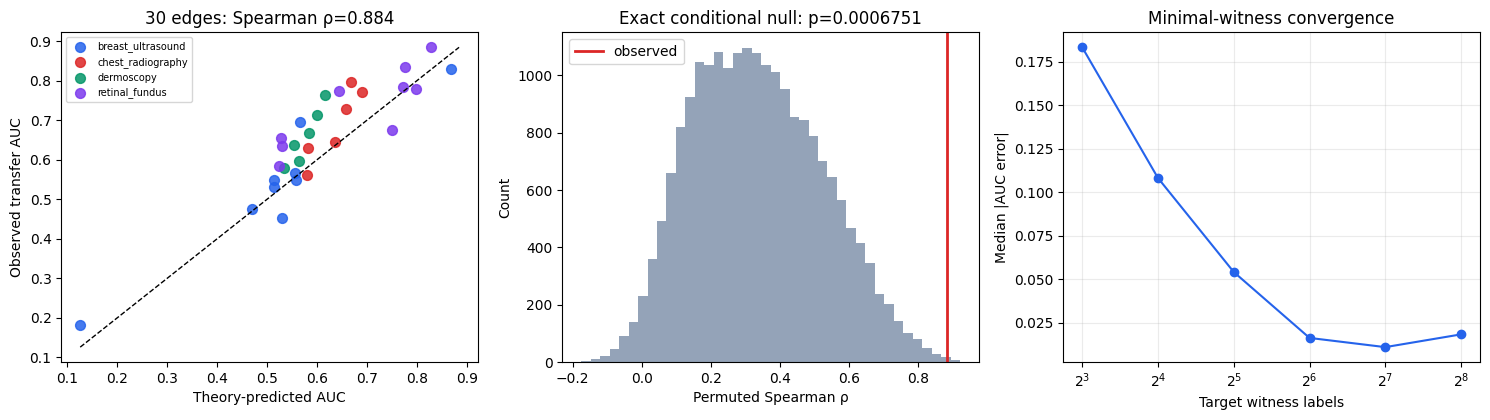

,gate,observed,required,passed
0,G1_global_monotonicity,0.883871,>=0.6,True
1,G2_cluster_bootstrap_lower_positive,0.585195,>0,True
2,G3_conditional_permutation,0.000675,<=0.01,True
3,G4_within_modality_consistency,positive=4; rho>=0.50=4,positive=4; rho>=0.50>=3,True
4,G5_leave_one_modality_robustness,0.855844,>=0.6,True
5,G6_absolute_auc_prediction,0.062902,<=0.08,True
6,G7_reciprocal_directionality,accuracy=0.750000; rho=0.727273,accuracy>=0.7; rho>=0.5,True
7,G8_mechanistic_gain,0.423669,>=0.25,True


================ STAGE T1-R COMPLETE ================
Global Spearman: 0.883871
Cluster bootstrap 95% CI: [0.585195, 0.965253]
Exact permutation p: 0.000675122
AUC MAE: 0.062902
Within-modality Spearman: {'breast_ultrasound': 0.8, 'chest_radiography': 0.942857, 'dermoscopy': 0.942857, 'retinal_fundus': 0.916667}
Reciprocal direction sign accuracy / delta rho: 0.750000 / 0.727273
Frozen gates: 8 / 8
Decision: AUTHORISE_DDET_MINIMAL_WITNESS_METHOD_DEVELOPMENT
Next step: BUILD_AND_FREEZE_CROSS_FITTED_MINIMAL_TARGET_WITNESS_ESTIMATOR_ON_DEVELOPMENT_DATA_ONLY
Stage 12 authorised: False
Locked-blind assets touched: False
Final record hash: 4d47c8e2d2df03482dca88cb7c6122a350f935649c55a162c3c312a6d6c3ff1c


In [6]:
# @title T1-R-5. Apply all frozen gates, write report, figures, firewall, manifest, and final record
t=THRESHOLDS
within_values=list(within.values()); lomo_values=list(lomo.values())
gate_rows=[
    {'gate':'G1_global_monotonicity','observed':global_rho,'required':f">={t['global_spearman_min']}",'passed':global_rho>=t['global_spearman_min']},
    {'gate':'G2_cluster_bootstrap_lower_positive','observed':cluster_ci[0],'required':'>0','passed':cluster_ci[0]>0},
    {'gate':'G3_conditional_permutation','observed':perm_p,'required':f"<={t['permutation_p_max']}",'passed':perm_p<=t['permutation_p_max']},
    {'gate':'G4_within_modality_consistency','observed':f"positive={sum(v>0 for v in within_values)}; rho>=0.50={sum(v>=.5 for v in within_values)}",'required':'positive=4; rho>=0.50>=3','passed':sum(v>0 for v in within_values)==4 and sum(v>=.5 for v in within_values)>=3},
    {'gate':'G5_leave_one_modality_robustness','observed':min(lomo_values),'required':f">={t['lomo_spearman_min']}",'passed':min(lomo_values)>=t['lomo_spearman_min']},
    {'gate':'G6_absolute_auc_prediction','observed':auc_mae,'required':f"<={t['auc_mae_max']}",'passed':auc_mae<=t['auc_mae_max']},
    {'gate':'G7_reciprocal_directionality','observed':f"accuracy={direction_accuracy:.6f}; rho={direction_rho:.6f}",'required':f"accuracy>={t['direction_sign_accuracy_min']}; rho>={t['direction_delta_spearman_min']}",'passed':direction_accuracy>=t['direction_sign_accuracy_min'] and direction_rho>=t['direction_delta_spearman_min']},
    {'gate':'G8_mechanistic_gain','observed':mechanistic_gain,'required':f">={t['mechanistic_gain_min']}",'passed':mechanistic_gain>=t['mechanistic_gain_min']},
]
gates=pd.DataFrame(gate_rows); write_csv_once(P3/'StageT1-R_Frozen_Viability_Gates_v0.1.csv',gates)
viable=bool(gates.passed.all())
decision=('AUTHORISE_DDET_MINIMAL_WITNESS_METHOD_DEVELOPMENT' if viable else 'TERMINATE_SINGLE_AXIS_DDET_REQUIRE_SUBSPACE_REDEFINITION')
next_step=('BUILD_AND_FREEZE_CROSS_FITTED_MINIMAL_TARGET_WITNESS_ESTIMATOR_ON_DEVELOPMENT_DATA_ONLY' if viable else 'STOP_SINGLE_AXIS_ROUTE_AND_REDEFINE_DIAGNOSTIC_SUBSPACE_UNDER_A_NEW_PROTOCOL')

fig,ax=plt.subplots(1,3,figsize=(15,4.3))
colors=dict(zip(sorted(mechanism.modality.unique()),['#2563eb','#dc2626','#059669','#7c3aed']))
for m,g in mechanism.groupby('modality'): ax[0].scatter(g.predicted_auc,g.target_auc,label=m,color=colors[m],s=50,alpha=.85)
lo=min(mechanism.predicted_auc.min(),mechanism.target_auc.min()); hi=max(mechanism.predicted_auc.max(),mechanism.target_auc.max())
ax[0].plot([lo,hi],[lo,hi],'--',color='black',lw=1); ax[0].set(xlabel='Theory-predicted AUC',ylabel='Observed transfer AUC',title=f'30 edges: Spearman ρ={global_rho:.3f}'); ax[0].legend(fontsize=7)
ax[1].hist(perm_rho,bins=40,color='#94a3b8'); ax[1].axvline(global_rho,color='#dc2626',lw=2,label='observed'); ax[1].set(xlabel='Permuted Spearman ρ',ylabel='Count',title=f'Exact conditional null: p={perm_p:.4g}'); ax[1].legend()
ax[2].plot(witness_summary.witness_labels,witness_summary.median_absolute_error,marker='o',color='#2563eb'); ax[2].set_xscale('log',base=2); ax[2].set(xlabel='Target witness labels',ylabel='Median |AUC error|',title='Minimal-witness convergence'); ax[2].grid(alpha=.25)
fig.tight_layout(); FIGURE=P4/'StageT1-R_DDET_Mechanism_And_Witness_v0.1.png'; fig.savefig(FIGURE,dpi=180,bbox_inches='tight'); plt.show()

def md_table(frame):
    x=frame.fillna('').astype(str); esc=lambda s:str(s).replace('|','\\|').replace('\n',' ')
    return '\n'.join(['| '+' | '.join(map(esc,x.columns))+' |','| '+' | '.join('---' for _ in x.columns)+' |']+['| '+' | '.join(map(esc,row))+' |' for row in x.itertuples(index=False,name=None)])
REPORT=P4/'StageT1-R_DDET_Mechanism_Kill_Test_Report_v0.1.md'
report=f'''# Stage T1-R DDET mechanism kill-test report

## Answer first

**Decision:** `{decision}`

The zero-fitted-parameter DDET marginal operational proxy achieved Spearman rho **{global_rho:.6f}** across 30 directed development edges. The two-way dataset-cluster bootstrap 95% interval was **[{cluster_ci[0]:.6f}, {cluster_ci[1]:.6f}]**; exact modality-stratified target-signature permutation p was **{perm_p:.6g}**; AUC MAE was **{auc_mae:.6f}**. Frozen gates passed: **{int(gates.passed.sum())}/{len(gates)}**.

This is oracle mechanism discovery because the target diagnostic axis is label-informed. Ordinary marginal score correlation is an operational approximation to the theorem's class-centred alignment. It authorises only development of a cross-fitted, class-centred minimal-witness estimator, not blind validation.

## Frozen gates

{md_table(gates)}

## Within-modality Spearman

{md_table(pd.DataFrame([{'modality':k,'spearman':v} for k,v in within.items()]))}

## Fixed comparisons

{md_table(pd.DataFrame([{'comparison':k,'spearman':v} for k,v in baselines.items()]))}

## Directionality

Reciprocal-pair sign accuracy: **{direction_accuracy:.6f}**. Reciprocal delta Spearman: **{direction_rho:.6f}**.

## Boundary

- Stage 11G-R remains a valid termination of DDO-2 v0.1.
- Existing 30 edges remain discovery-only.
- Stage 12 authorised: **False**.
- Locked-blind assets touched: **False**.
- Next step: `{next_step}`.
'''
write_text_once(REPORT,report)

checks=pd.DataFrame([
    {'check':'parent_edge_library_exact','passed':sha_file(EDGE_PATH)==EXPECTED_EDGE_SHA256,'evidence':sha_file(EDGE_PATH)},
    {'check':'theory_and_prereg_exact','passed':sha_file(THEORY_PATH)==EXPECTED_THEORY_SHA256 and sha_file(PREREG_PATH)==EXPECTED_PREREG_SHA256,'evidence':protocol['seal_sha256']},
    {'check':'stage11g_termination_preserved','passed':str(stage11g['decision']).startswith('TERMINATE_DDO2_V0_1'),'evidence':stage11g['decision']},
    {'check':'thirty_edges_four_modalities_fourteen_domains','passed':len(mechanism)==30 and mechanism.modality.nunique()==4 and len(set(mechanism.source)|set(mechanism.target))==14,'evidence':f'{len(mechanism)}/{mechanism.modality.nunique()}/{len(set(mechanism.source)|set(mechanism.target))}'},
    {'check':'zero_edge_outcome_coefficients_fitted','passed':protocol['edge_outcome_coefficients_fitted'] is False,'evidence':'theory identity only'},
    {'check':'exact_permutation_complete','passed':len(perm_rho)==20736,'evidence':len(perm_rho)},
    {'check':'bootstrap_complete','passed':len(bootstrap)>=9900,'evidence':len(bootstrap)},
    {'check':'decision_matches_all_gates','passed':viable==bool(gates.passed.all()),'evidence':decision},
    {'check':'stage12_not_authorised','passed':True,'evidence':False},
    {'check':'locked_blind_assets_not_touched','passed':not any(m.lower() in resolved.lower() for m in LOCKED_MARKERS),'evidence':False},
])
assert checks.passed.all(),checks.loc[~checks.passed]
FIREWALL=P4/'StageT1-R_Independent_Firewall_Checks_v0.1.csv'; write_csv_once(FIREWALL,checks)
MANIFEST=P4/'StageT1-R_Output_Integrity_Manifest_v0.1.csv'; FINAL=P4/'StageT1-R_Complete_v0.1.json'
tracked=[]
for p in sorted(RESULT_ROOT.rglob('*')):
    if p.is_file() and p not in {MANIFEST,FINAL}:
        tracked.append({'relative_path':str(p.relative_to(RESULT_ROOT)),'size_bytes':p.stat().st_size,'sha256':sha_file(p)})
write_csv_once(MANIFEST,pd.DataFrame(tracked))
final_payload={'stage':'StageT1-R','decision':decision,'next_step':next_step,'protocol_seal_sha256':protocol['seal_sha256'],
    'parent_edge_library_sha256':sha_file(EDGE_PATH),'theory_sha256':sha_file(THEORY_PATH),'preregistration_sha256':sha_file(PREREG_PATH),
    'mechanism_table_sha256':sha_file(P2/'StageT1-R_DDET_Thirty_Edge_Mechanism_Table_v0.1.csv'),
    'gates_sha256':sha_file(P3/'StageT1-R_Frozen_Viability_Gates_v0.1.csv'),'report_sha256':sha_file(REPORT),
    'firewall_sha256':sha_file(FIREWALL),'output_manifest_sha256':sha_file(MANIFEST),'global_spearman':global_rho,
    'cluster_bootstrap_ci95':cluster_ci,'permutation_p_one_sided':perm_p,'auc_mae':auc_mae,
    'gates_passed':int(gates.passed.sum()),'gates_total':len(gates),'single_axis_mechanism_viable':viable,
    'target_axis_label_informed':True,'existing_edges_discovery_only':True,'stage12_authorised':False,'locked_blind_assets_touched':False}
final=seal(FINAL,final_payload,'final_record_sha256','completed_utc')
display(gates)
print('================ STAGE T1-R COMPLETE ================')
print('Global Spearman:',f'{global_rho:.6f}')
print('Cluster bootstrap 95% CI:',f'[{cluster_ci[0]:.6f}, {cluster_ci[1]:.6f}]')
print('Exact permutation p:',f'{perm_p:.6g}')
print('AUC MAE:',f'{auc_mae:.6f}')
print('Within-modality Spearman:',{k:round(v,6) for k,v in within.items()})
print('Reciprocal direction sign accuracy / delta rho:',f'{direction_accuracy:.6f}', '/', f'{direction_rho:.6f}')
print('Frozen gates:',int(gates.passed.sum()),'/',len(gates))
print('Decision:',decision)
print('Next step:',next_step)
print('Stage 12 authorised: False')
print('Locked-blind assets touched: False')
print('Final record hash:',final['final_record_sha256'])
